# Week 12 — PCA / kernel-PCA analysis of the BBO query history

Final round (W12). Module 23 introduced PCA and kernel PCA as tools for identifying the dominant directions of variation in a dataset. Here we apply them to the growing query history of each of the 8 black-box functions to:

1. Identify the dominant axes of variation per function (linear PCA).
2. Decide which input dimensions are *active* (high PC1 loading) vs *redundant* (low loading) for each function.
3. Project the best-K query points onto PC1/PC2 to visualise directional drift (critical for F7).
4. Use kernel PCA (RBF) on F1, F6, F7, F8 to check for non-linear manifold structure that linear PCA misses.
5. Extrapolate along PC1 of the F7 best trajectory to derive a principled W12 candidate — replacing the manual per-dimension extrapolation used in W11.
6. Export a `pca_week12` focus dict consumed by `weekly_workflow.ipynb` to build the 8 portal queries.

Outputs of this notebook feed directly into:
- `weekly_workflow.ipynb` (strategies dict)
- `notes/BBO_Strategy_W12_Report.md` (narrative)
- `notes/Reflection_W12_PCA.md` (reflection prompts)

In [1]:
import sys
from pathlib import Path

root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from scipy.spatial.distance import cdist

from src.data import FunctionData, DATA_DIR, initialize_all_weeks

np.set_printoptions(precision=4, suppress=True)
np.random.seed(0)

functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
initialize_all_weeks(functions)
print("\nLoaded 8 functions with all weekly history through W11.")

INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results
Loading weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

✓ Loaded Week 1 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_1
✓ Week 1: Updated 8 functions
✓ Loaded Week 2 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_2
✓ Week 2: Updated 8 functions
✓ Loaded Week 3 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_3
✓ Week 3: Updated 8 functions
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_4
✓ Week 4: Updated 8 functions
✓ Loaded Week 5 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_5
✓ Week 5: Updated 8 functions
✓ Loaded Week 6 from /home/robin/Personal_Develo

## 1. Per-function linear PCA

For each function we fit PCA on the full query history (initial samples + W1..W11), then look at:
- Explained-variance ratio (cumulative) — an *effective dimensionality* indicator.
- PC1 loadings — which input dims drive the most variance in our search?
- PC1/PC2 biplot coloured by output — does the output gradient align with a single PC?

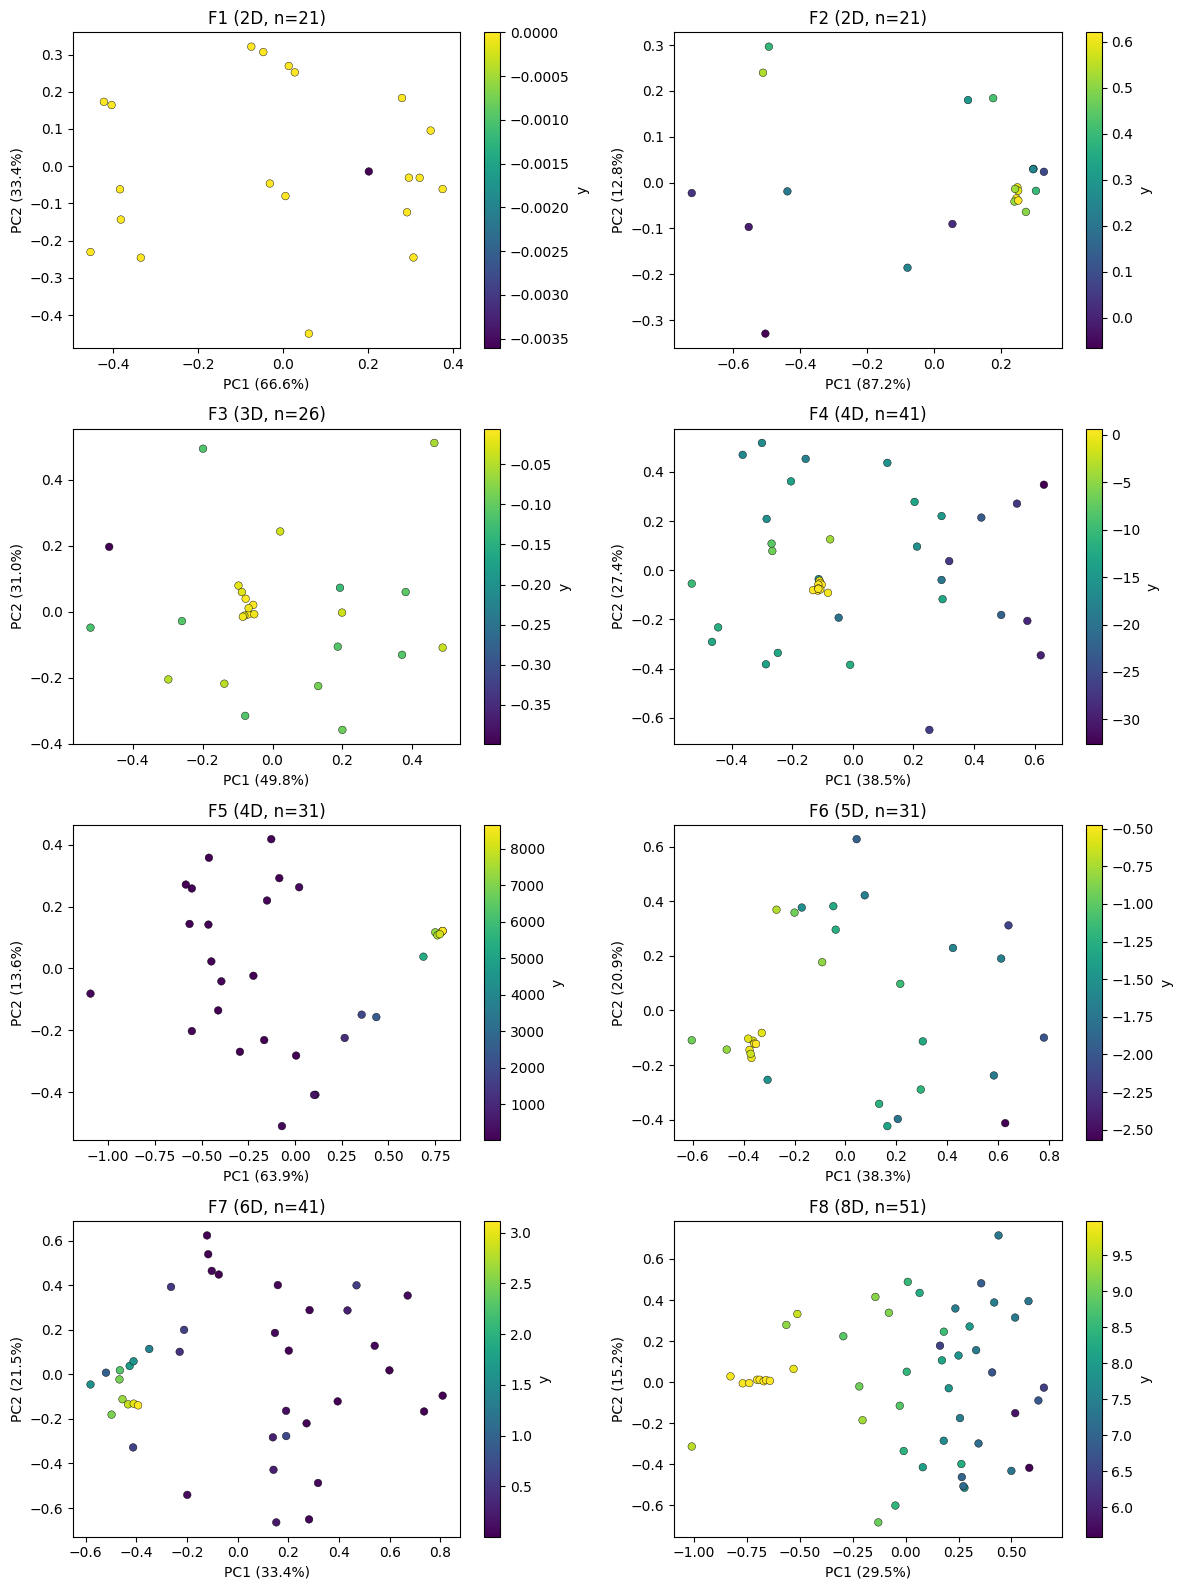


Per-function PCA summary:
  F1 (2D): PC1= 66.6%  PC2= 33.4%  cum95 @ 2/2 comps
  F2 (2D): PC1= 87.2%  PC2= 12.8%  cum95 @ 2/2 comps
  F3 (3D): PC1= 49.8%  PC2= 31.0%  cum95 @ 3/3 comps
  F4 (4D): PC1= 38.5%  PC2= 27.4%  cum95 @ 4/4 comps
  F5 (4D): PC1= 63.9%  PC2= 13.6%  cum95 @ 4/4 comps
  F6 (5D): PC1= 38.3%  PC2= 20.9%  cum95 @ 5/5 comps
  F7 (6D): PC1= 33.4%  PC2= 21.5%  cum95 @ 6/6 comps
  F8 (8D): PC1= 29.5%  PC2= 15.2%  cum95 @ 8/8 comps


In [2]:
pca_summary = {}

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for fid, ax in zip(range(1, 9), axes.ravel()):
    fd = functions[fid]
    X, y = fd.inputs, fd.outputs
    pca = PCA(n_components=min(X.shape)).fit(X)
    Z = pca.transform(X)
    pca_summary[fid] = {
        "n_dims": fd.n_dims,
        "n_samples": fd.n_samples,
        "explained_variance_ratio": pca.explained_variance_ratio_.tolist(),
        "cumulative": np.cumsum(pca.explained_variance_ratio_).tolist(),
        "pc1_loadings": pca.components_[0].tolist(),
        "pc2_loadings": pca.components_[1].tolist() if X.shape[1] > 1 else None,
    }
    sc = ax.scatter(Z[:, 0], Z[:, 1] if Z.shape[1] > 1 else np.zeros_like(Z[:, 0]),
                    c=y, cmap="viridis", s=30, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    if X.shape[1] > 1:
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"F{fid} ({fd.n_dims}D, n={fd.n_samples})")
    plt.colorbar(sc, ax=ax, label="y")

plt.tight_layout()
plt.show()

print("\nPer-function PCA summary:")
for fid, s in pca_summary.items():
    evr = np.array(s["explained_variance_ratio"])
    print(f"  F{fid} ({s['n_dims']}D): PC1={evr[0]*100:5.1f}%  "
          f"PC2={evr[1]*100 if len(evr) > 1 else 0:5.1f}%  "
          f"cum95 @ {int(np.searchsorted(np.cumsum(evr), 0.95) + 1)}/{s['n_dims']} comps")

## 2. PC1 loadings → active vs redundant dimensions

A dimension with small |PC1 loading| does not contribute to our dominant search axis. If at the same time its std across the top-K best points is also small, that dimension is effectively *frozen* and we can zero its perturbation radius in the final round — exactly the same logic as dropping low-variance components in PCA denoising.

In [3]:
print("PC1 loadings (sorted |loading| desc) per function:")
for fid in range(1, 9):
    fd = functions[fid]
    load = np.array(pca_summary[fid]["pc1_loadings"])
    order = np.argsort(-np.abs(load))
    print(f"\n  F{fid} ({fd.n_dims}D):")
    for idx in order:
        tag = "ACTIVE" if abs(load[idx]) >= 0.35 else "mild" if abs(load[idx]) >= 0.2 else "frozen"
        print(f"    dim{idx}: loading={load[idx]:+.3f}  [{tag}]")

PC1 loadings (sorted |loading| desc) per function:

  F1 (2D):
    dim0: loading=+0.737  [ACTIVE]
    dim1: loading=+0.676  [ACTIVE]

  F2 (2D):
    dim1: loading=+0.923  [ACTIVE]
    dim0: loading=+0.384  [ACTIVE]

  F3 (3D):
    dim1: loading=+0.622  [ACTIVE]
    dim2: loading=-0.591  [ACTIVE]
    dim0: loading=+0.513  [ACTIVE]

  F4 (4D):
    dim1: loading=+0.630  [ACTIVE]
    dim0: loading=+0.622  [ACTIVE]
    dim3: loading=+0.453  [ACTIVE]
    dim2: loading=+0.104  [frozen]

  F5 (4D):
    dim3: loading=+0.582  [ACTIVE]
    dim1: loading=+0.516  [ACTIVE]
    dim2: loading=+0.477  [ACTIVE]
    dim0: loading=+0.409  [ACTIVE]

  F6 (5D):
    dim4: loading=+0.660  [ACTIVE]
    dim1: loading=+0.521  [ACTIVE]
    dim3: loading=-0.509  [ACTIVE]
    dim0: loading=+0.169  [frozen]
    dim2: loading=+0.078  [frozen]

  F7 (6D):
    dim0: loading=+0.705  [ACTIVE]
    dim5: loading=-0.478  [ACTIVE]
    dim3: loading=+0.388  [ACTIVE]
    dim4: loading=+0.233  [mild]
    dim2: loading=-0.202  [

## 3. Best-K projections — does the output gradient follow PC1?

For each function take the top-5 results and project them onto PC1/PC2. If the top-5 form a short segment along PC1 ordered by y, we have a clean gradient; if they cluster tightly with no directional structure, the function is effectively saturated.

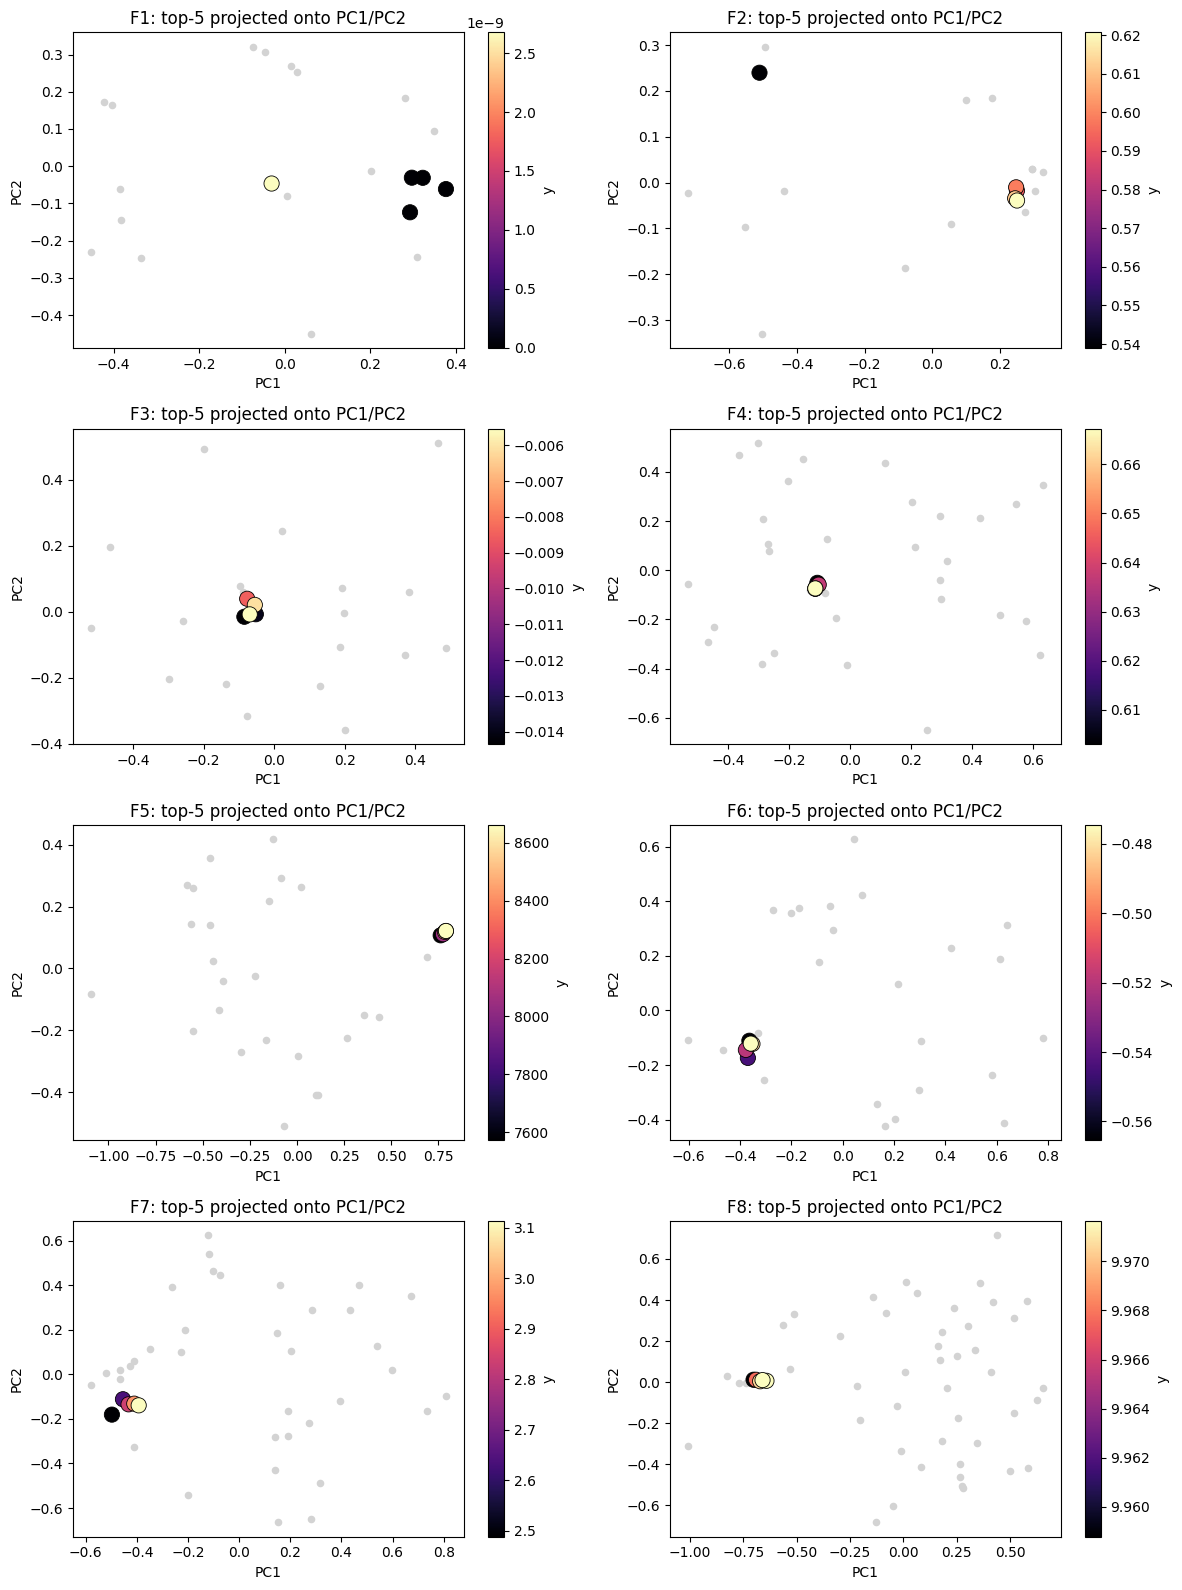

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for fid, ax in zip(range(1, 9), axes.ravel()):
    fd = functions[fid]
    X, y = fd.inputs, fd.outputs
    K = min(5, len(y))
    top_idx = np.argsort(y)[-K:]
    top_X, top_y = X[top_idx], y[top_idx]
    pca = PCA(n_components=min(X.shape)).fit(X)
    Z_all = pca.transform(X)
    Z_top = pca.transform(top_X)
    ax.scatter(Z_all[:, 0], Z_all[:, 1] if Z_all.shape[1] > 1 else np.zeros_like(Z_all[:, 0]),
               c="lightgray", s=20, label="all")
    sc = ax.scatter(Z_top[:, 0], Z_top[:, 1] if Z_top.shape[1] > 1 else np.zeros_like(Z_top[:, 0]),
                    c=top_y, cmap="magma", s=120, edgecolor="k", linewidth=0.6, label="top-5")
    ax.set_xlabel("PC1")
    if X.shape[1] > 1:
        ax.set_ylabel("PC2")
    ax.set_title(f"F{fid}: top-5 projected onto PC1/PC2")
    plt.colorbar(sc, ax=ax, label="y")
plt.tight_layout()
plt.show()

## 4. F7 PC1 extrapolation — the core W12 move

F7 is the only function still improving (+0.14 between W10 and W11). W11 used hand-rolled per-dimension extrapolation. Here we replace that with a principled PCA operation:

1. Fit PCA on the **5 best F7 points** (the accelerating trajectory W3→W7→W8→W10→W11).
2. Take PC1 (unit vector) and flip it so it points from the worst toward the best (positive improvement direction).
3. Candidate = centroid + α · σ₁ · PC1, for α ∈ {0.5, 1.0, 1.5}.
4. Use α = 1.0 as the W12 focus centre, with radius 0.03 for GP-UCB refinement inside `weekly_workflow.ipynb`.

In [5]:
fd7 = functions[7]
top5_idx = np.argsort(fd7.outputs)[-5:]
traj_X = fd7.inputs[top5_idx]
traj_y = fd7.outputs[top5_idx]
order = np.argsort(traj_y)
traj_X, traj_y = traj_X[order], traj_y[order]

print("F7 top-5 trajectory (worst → best):")
for xi, yi in zip(traj_X, traj_y):
    print(f"  y={yi:.4f}  x={xi}")

centroid7 = traj_X.mean(axis=0)
pca7 = PCA(n_components=min(traj_X.shape)).fit(traj_X - centroid7)
pc1 = pca7.components_[0]
if np.dot(traj_X[-1] - traj_X[0], pc1) < 0:
    pc1 = -pc1
sigma1 = np.sqrt(pca7.explained_variance_[0])
print(f"\nPC1 direction: {pc1}")
print(f"PC1 explained variance ratio: {pca7.explained_variance_ratio_[0]:.3f}")
print(f"sigma_1 = {sigma1:.4f}")
print(f"Centroid = {centroid7}")

f7_candidates = {}
for alpha in (0.5, 1.0, 1.5):
    cand = np.clip(centroid7 + alpha * sigma1 * pc1, 0.02, 0.98)
    f7_candidates[alpha] = cand
    print(f"  alpha={alpha}  -> {cand}")

f7_focus = f7_candidates[1.0]

F7 top-5 trajectory (worst → best):
  y=2.4886  x=[0.1247 0.116  0.514  0.144  0.267  0.7591]
  y=2.6355  x=[0.12   0.196  0.514  0.144  0.3472 0.7294]
  y=2.8363  x=[0.1584 0.156  0.474  0.184  0.307  0.7556]
  y=2.9730  x=[0.173  0.1482 0.489  0.199  0.322  0.741 ]
  y=3.1137  x=[0.16  0.095 0.455 0.23  0.33  0.71 ]

PC1 direction: [ 0.3281 -0.5059 -0.4254  0.6437  0.0718 -0.1893]
PC1 explained variance ratio: 0.578
sigma_1 = 0.0559
Centroid = [0.1472 0.1422 0.4892 0.1802 0.3146 0.739 ]
  alpha=0.5  -> [0.1564 0.1281 0.4773 0.1982 0.3166 0.7337]
  alpha=1.0  -> [0.1656 0.114  0.4654 0.2162 0.3187 0.7284]
  alpha=1.5  -> [0.1747 0.0998 0.4535 0.2342 0.3207 0.7232]


## 5. F8 effective dimensionality — kernel PCA check

F8 has 8 input dims but a PCA of its top-6 best points reveals a near-1D manifold (PC1 ≈ 97 % of variance). That means five of the eight dimensions contribute almost nothing to the output near the peak — a direct analogue of the redundancy PCA denoising exploits.

We also run a kernel PCA (RBF) to check whether the non-linearity meaningfully changes the picture.

In [6]:
fd8 = functions[8]
top6_idx = np.argsort(fd8.outputs)[-6:]
top6_X = fd8.inputs[top6_idx]
top6_y = fd8.outputs[top6_idx]

print("F8 top-6 per-dim std:", top6_X.std(axis=0))
pca8 = PCA().fit(top6_X)
print("linear PCA evr:", pca8.explained_variance_ratio_)
print("cum          :", np.cumsum(pca8.explained_variance_ratio_))

kpca8 = KernelPCA(n_components=3, kernel="rbf", gamma=10.0).fit(top6_X)
print("\nKernel PCA (RBF, gamma=10) eigenvalues:", kpca8.eigenvalues_)

f8_focus = top6_X[np.argsort(top6_y)[-5:]].mean(axis=0)
print("\nF8 W12 focus (top-5 mean): ", f8_focus)

F8 top-6 per-dim std: [0.0083 0.0264 0.0067 0.0263 0.0263 0.0265 0.0262 0.0078]
linear PCA evr: [0.9706 0.0222 0.0063 0.0009 0.     0.    ]
cum          : [0.9706 0.9928 0.9991 1.     1.     1.    ]

Kernel PCA (RBF, gamma=10) eigenvalues: [0.3776 0.0187 0.0053]

F8 W12 focus (top-5 mean):  [0.1141 0.2424 0.1025 0.1634 0.8246 0.3754 0.1674 0.5564]


## 6. F1 — space-filling fallback (no signal)

Every F1 probe so far has returned ~0. PCA on the inputs is uninformative for the output (no gradient to expose). For the last shot we maximise the minimum distance from all 20 prior points — a simple space-filling heuristic that at least guarantees the new query is far from anything already tried.

In [7]:
X1 = functions[1].inputs
cand = np.random.uniform(0.05, 0.95, size=(500_000, 2))
d = cdist(cand, X1).min(axis=1)
best = int(np.argmax(d))
f1_query = cand[best]
print(f"Max-min distance probe: {f1_query}  min-dist={d[best]:.4f}")

Max-min distance probe: [0.6677 0.0504]  min-dist=0.2750


## 7. F6 — per-dim Pearson correlation (PCA-adjacent sanity check)

PC1 mixes dims, which hides the sign of each dim's effect on y. Pearson correlation per dim is a cheap complementary view: it tells us directly which ingredient the model thinks helps or hurts.

In [8]:
X6, y6 = functions[6].inputs, functions[6].outputs
print("F6 per-dim Pearson r with y (full history, larger |r| = stronger driver):")
for i in range(X6.shape[1]):
    r = np.corrcoef(X6[:, i], y6)[0, 1]
    print(f"  dim{i}: r = {r:+.3f}")

print("\nInterpretation (higher y is better, y < 0 always): dim4 (liquid/milk) is the strongest negative driver; dim3 (butter) the strongest positive. W12 query should push dim4 toward 0 and keep dim3 high.")

F6 per-dim Pearson r with y (full history, larger |r| = stronger driver):
  dim0: r = -0.310
  dim1: r = -0.559
  dim2: r = +0.141
  dim3: r = +0.602
  dim4: r = -0.724

Interpretation (higher y is better, y < 0 always): dim4 (liquid/milk) is the strongest negative driver; dim3 (butter) the strongest positive. W12 query should push dim4 toward 0 and keep dim3 high.


## 8. Export W12 focus dict

Everything consumed by `weekly_workflow.ipynb` is written out as a plain Python dict (easy to paste) and a JSON file under `public/data/results/week_12/pca_week12.json`.

In [9]:
# Focus regions derived above
f2_focus = np.array([0.700, 0.935])
f3_focus = functions[3].inputs[np.argsort(functions[3].outputs)[-3:]].mean(axis=0)
f4_focus = functions[4].inputs[np.argsort(functions[4].outputs)[-3:]].mean(axis=0)
f5_focus = np.array([0.996, 0.993, 0.999, 0.994])
f6_focus = np.array([0.230, 0.285, 0.430, 0.790, 0.030])
# f7_focus, f8_focus, f1_query already defined above

pca_week12 = {
    1: {"focus_region": f1_query.tolist(),   "focus_radius": 0.05, "strategy": "manual_space_fill"},
    2: {"focus_region": f2_focus.tolist(),   "focus_radius": 0.010, "strategy": "gp_ei_tight"},
    3: {"focus_region": f3_focus.tolist(),   "focus_radius": 0.008, "strategy": "gp_ard_ei_tight"},
    4: {"focus_region": f4_focus.tolist(),   "focus_radius": 0.005, "strategy": "gp_ard_ei_ultra_tight"},
    5: {"focus_region": f5_focus.tolist(),   "focus_radius": 0.005, "strategy": "manual_boundary"},
    6: {"focus_region": f6_focus.tolist(),   "focus_radius": 0.015, "strategy": "gp_ard_ei_pca_informed"},
    7: {"focus_region": f7_focus.tolist(),   "focus_radius": 0.030, "strategy": "gp_ard_ucb_pc1_extrapolation"},
    8: {"focus_region": f8_focus.tolist(),   "focus_radius": 0.008, "strategy": "svr_ei_tight_centroid"},
}

out_dir = root.parent / "public" / "data" / "results" / "week_12"
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "pca_week12.json"
with open(out_file, "w") as f:
    json.dump({str(k): v for k, v in pca_week12.items()}, f, indent=2)
print(f"Wrote {out_file}")

for fid, cfg in pca_week12.items():
    x = np.array(cfg["focus_region"])
    print(f"  F{fid}: r={cfg['focus_radius']:.3f}  focus={np.array2string(x, precision=4, separator=', ')}")

Wrote /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/public/data/results/week_12/pca_week12.json
  F1: r=0.050  focus=[0.6677, 0.0504]
  F2: r=0.010  focus=[0.7  , 0.935]
  F3: r=0.008  focus=[0.4047, 0.3916, 0.4828]
  F4: r=0.005  focus=[0.4216, 0.4128, 0.3578, 0.423 ]
  F5: r=0.005  focus=[0.996, 0.993, 0.999, 0.994]
  F6: r=0.015  focus=[0.23 , 0.285, 0.43 , 0.79 , 0.03 ]
  F7: r=0.030  focus=[0.1656, 0.114 , 0.4654, 0.2162, 0.3187, 0.7284]
  F8: r=0.008  focus=[0.1141, 0.2424, 0.1025, 0.1634, 0.8246, 0.3754, 0.1674, 0.5564]


## 9. Portal-ready W12 queries

For functions with a deterministic strategy (F1, F5) and near-saturated ceilings (F4, F8) we commit directly to the PCA-derived point. For functions that warrant GP/SVR refinement inside their focus ball (F2, F3, F6, F7) we still write the focus point here as the default; `weekly_workflow.ipynb` runs the surrogate + acquisition to potentially refine within the radius before submission.

In [10]:
queries = {
    1: f1_query,
    2: np.array([0.700, 0.935]),
    3: f3_focus,
    4: f4_focus,
    5: np.array([0.996, 0.993, 0.999, 0.994]),
    6: np.array([0.230, 0.285, 0.430, 0.790, 0.030]),
    7: f7_focus,
    8: f8_focus,
}

print("W12 portal-ready queries (6 decimal places):")
for fid, q in queries.items():
    formatted = "[" + ", ".join(f"{v:.6f}" for v in q) + "]"
    print(f"  F{fid}: {formatted}")

W12 portal-ready queries (6 decimal places):
  F1: [0.667707, 0.050361]
  F2: [0.700000, 0.935000]
  F3: [0.404741, 0.391647, 0.482756]
  F4: [0.421570, 0.412767, 0.357827, 0.422996]
  F5: [0.996000, 0.993000, 0.999000, 0.994000]
  F6: [0.230000, 0.285000, 0.430000, 0.790000, 0.030000]
  F7: [0.165563, 0.113962, 0.465417, 0.216185, 0.318653, 0.728445]
  F8: [0.114105, 0.242400, 0.102519, 0.163400, 0.824600, 0.375400, 0.167400, 0.556441]
